# Practice 6.
##  Objectives:
1. Understand the decision trees for the case of classification.
2. See the effects of changing the parameters of the tree.

## Aplication:
Data base: Datasets for "The Elements of Statistical Learning"
(https://web.stanford.edu/~hastie/ElemStatLearn/data.html)

 Database: coronary heart disease (CHD), https://web.stanford.edu/~hastie/ElemStatLearn/datasets/SAheart.data
- Predict **CHD** (1 or  0)


In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV



In [6]:
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T

Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\SixthPractice\Data\SouthAfricanHeartDesease.csv


,0,1,2,3,4
row.names,1,2,3,4,5
sbp,160,144,118,170,134
tobacco,12.0,0.01,0.08,7.5,13.6
ldl,5.73,4.41,3.48,6.41,3.5
adiposity,23.11,28.61,32.28,38.03,27.78
famhist,Present,Absent,Present,Present,Present
typea,49,55,52,51,60
obesity,25.3,28.87,29.14,31.99,25.99
alcohol,97.2,2.06,3.81,24.26,57.34
age,52,63,46,58,49


## Clean the database
###  Check there is no problem

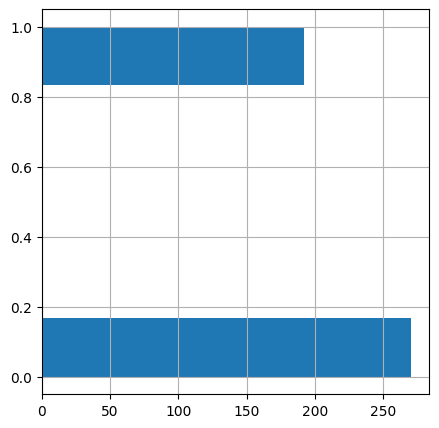

In [7]:
Coding_famhist ={'Present':1,'Absent':0}
Data['famhist'] = Data['famhist'].map(Coding_famhist)
ax =Data['famhist'].hist(figsize= (5,5),orientation="horizontal",bins = 6)

Data.drop(columns = ['row.names'],inplace = True)

### Let us see if the data is balanced

Note: predicted qualities are almost balanced 


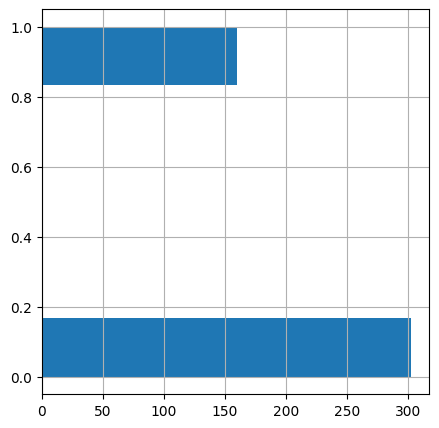

In [8]:
ax =Data['chd'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

##  Let us see the histograms

###  Features that would give problems in a Linear Classifier, PCA, LDA, and others

1- **Different units** between features. Note that Decision Trees are robust to this feature, while in other ML techniques you should consider standarize (see practice 5)

2- Some features are not **Gaussian**

3- Some features have high **Standard Deviation**  (this is a problem for algorithms based on correlations)

4- Note that tobaco and alcohol have the median (percentile 50%) quite different from the mean. Also in these cases the standard deviation is bigger than the mean. In the future we will deal with features with these properties.

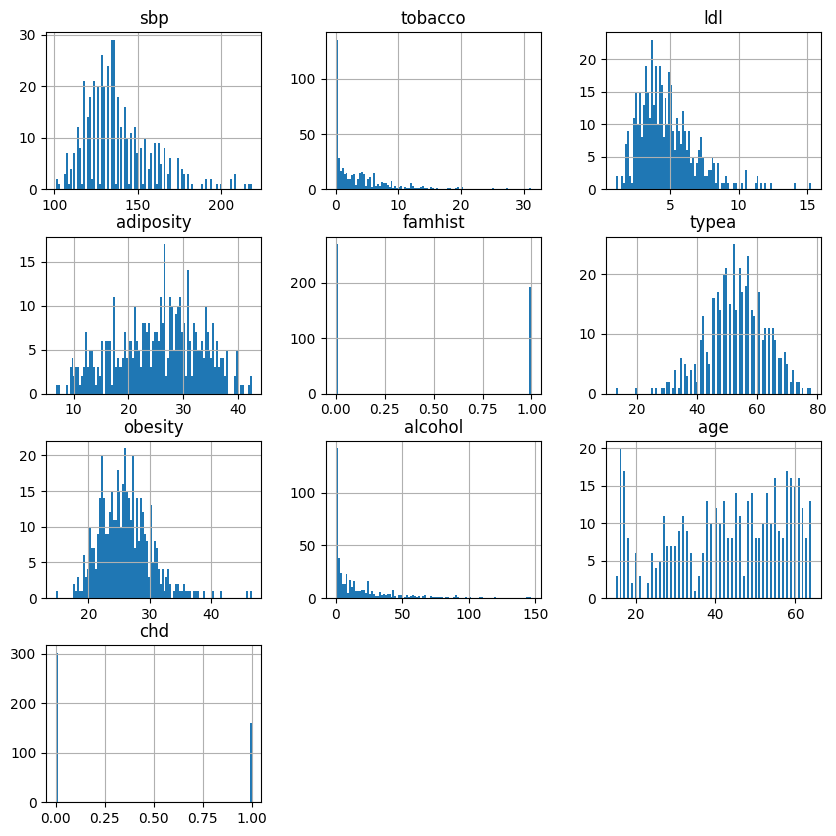

In [9]:
ax =Data.hist(figsize= (10,10),bins = 100)

### Excercise: <font color='red'> If we were working with a linear regression method, suggest a transformation for the variables tabaco and alcohol that might improve the working of the linear regression.</font>
**Spoiler:**  In decision trees it is not necessary. Explain why?

<font color='green'> If we were working with a linear regression method, suggest a transformation for the variables tabaco and alcohol that might improve the working of the linear regression.</font>

For tabaco and for alcohol a logarithmic transfomration might be useful, beacuse it would reduce te scale of both variables and standarize them. Then would the regression coeficientes would be more precise and not affected that much form the scale change. Also notice that in both variables there are heavy outliers.

In decision trees is not necessary to standarize beacuse the questions we define in the nodes are only affected by the feature itself, so is not going to be realated with other variable units or scale.

In [10]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sbp,462.0,138.33,20.50,101.00,124.00,134.00,148.00,218.00
tobacco,462.0,3.64,4.59,0.00,0.05,2.00,5.50,31.20
ldl,462.0,4.74,2.07,0.98,3.28,4.34,5.79,15.33
adiposity,462.0,25.41,7.78,6.74,19.77,26.12,31.23,42.49
famhist,462.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
typea,462.0,53.10,9.82,13.00,47.00,53.00,60.00,78.00
obesity,462.0,26.04,4.21,14.70,22.98,25.80,28.50,46.58
alcohol,462.0,17.04,24.48,0.00,0.51,7.51,23.89,147.19
age,462.0,42.82,14.61,15.00,31.00,45.00,55.00,64.00
chd,462.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## Let us look into the scatter plot matrix to see if there is a regularity in the data

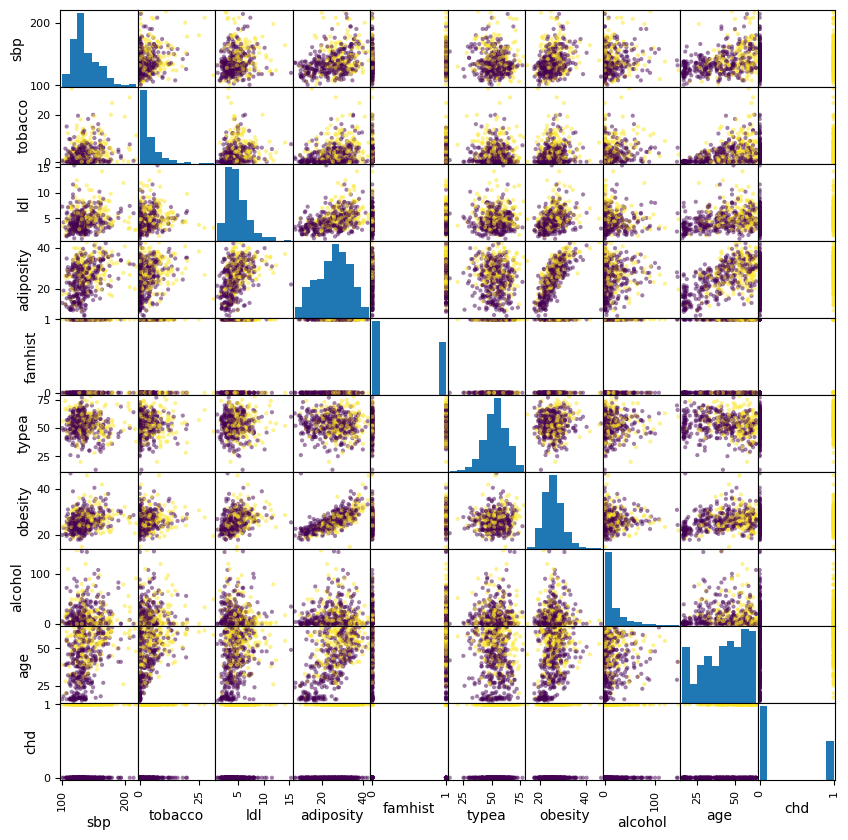

In [ ]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['chd'], figsize = (10,10))

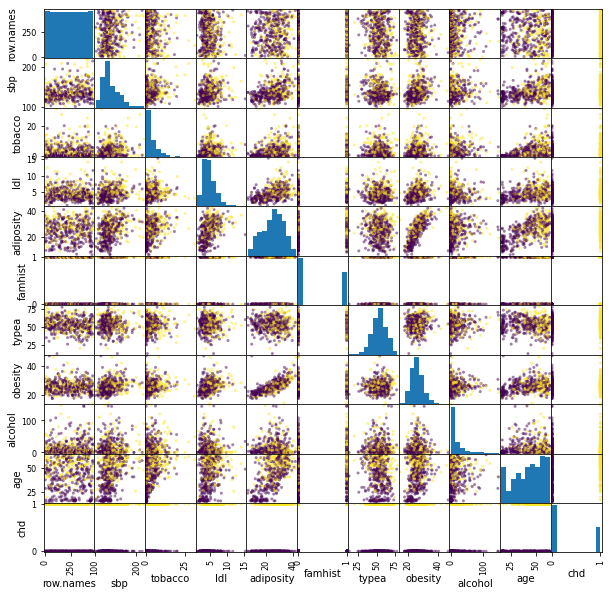

### Excercise: <font color='red'> Note that adiposity and obesity input variables are correlated .</font>
1. Explain *briefly*, why this is bad in the case of linear regression (or similar procedures).
2. Explain *briefly*, why in decision trees this is not so important.

<font color='green'> Note that adiposity and obesity input variables are correlated .</font>

In linear regression colinearity or correlation in the input variables is bad because beacuse it doesn't allow to keep one constant while changing the other feature, and this makes really difficult to differentiate the inidivudal effects of X1 and X2, making the reulting coefficients unreliable. In a mathematical point of view, if we look in to the formular of Linear Regression (XtX)^-1(XtY), the first term is very sensitive to colinearity.

In decision trees is not important beacuse every the architecture of them doesn't rely on global coefficients or assumtipons about the relationship between the variables, if 2 variables are correlated there is no problem if we have a question from one feature first and the other one later.

## Let us train a classifier

##  First we partition database into train and test
### Note the helper function

In [12]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [13]:
y = TrainDB['chd']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'chd']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']
__________________________________________________


### We create the decision tree object and fit the model to the Training database.

In [14]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

##  We print the decision rules that explain how the **diagnosis** is **explained** by the data.

1. ###  Note the hierarchy of variables. 
1. ###  Note the depth of the tree.

<font color='blue'> **Concept:** Works like a look up table. </font>

In [15]:
r = export_text(clf, feature_names=InputFeatures)
print(r)

|--- age <= 49.50
|   |--- tobacco <= 0.49
|   |   |--- obesity <= 18.48
|   |   |   |--- tobacco <= 0.05
|   |   |   |   |--- class: 1
|   |   |   |--- tobacco >  0.05
|   |   |   |   |--- class: 0
|   |   |--- obesity >  18.48
|   |   |   |--- typea <= 72.50
|   |   |   |   |--- age <= 39.50
|   |   |   |   |   |--- typea <= 66.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- typea >  66.50
|   |   |   |   |   |   |--- obesity <= 22.22
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- obesity >  22.22
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  39.50
|   |   |   |   |   |--- age <= 43.00
|   |   |   |   |   |   |--- sbp <= 139.00
|   |   |   |   |   |   |   |--- alcohol <= 2.06
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- alcohol >  2.06
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- sbp >  139.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |

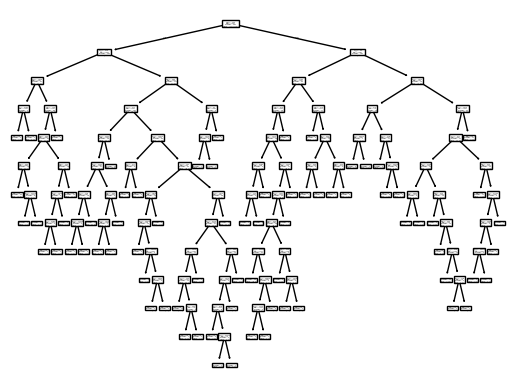

In [16]:
tree.plot_tree(clf)
plt.show()

### Excercise: <font color='red'> Provide a short common sense explanation of why a tree that works like a **look up table** is a bad solution .</font>

<font color='green'> Provide a short common sense explanation of why a tree that works like a **look up table** is a bad solution .</font>

A decision tree that behaves lika a look up table is a bad solution, beacuse it memorizes the training examples instead of learning general patterns. This makes the model perform very well with known data, but not that good with unseen patients (overfitting).

### Next we look at the details of the higher levels.

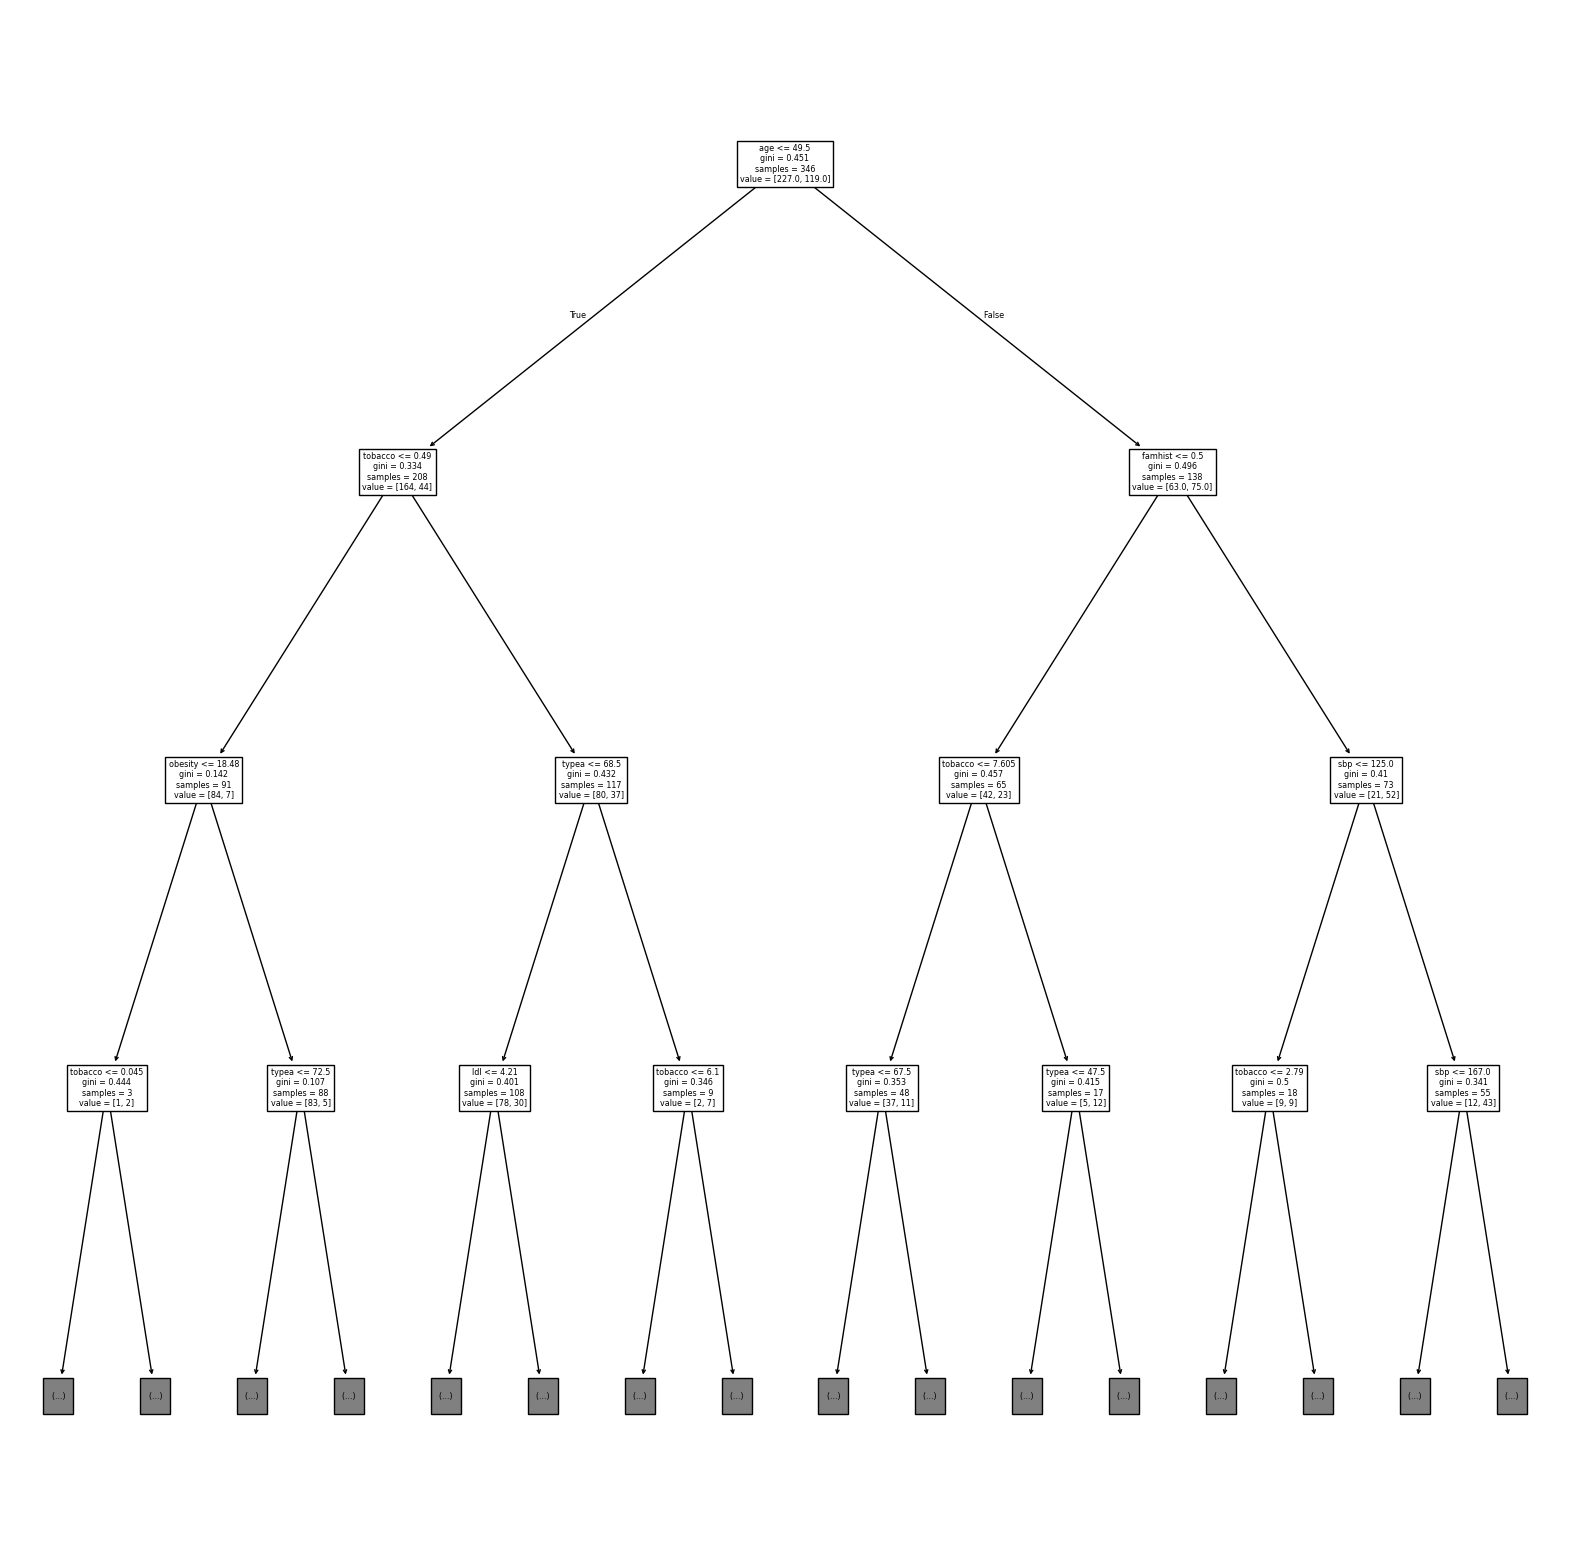

In [18]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(clf,max_depth = 3,feature_names = InputFeatures,impurity = True)
plt.show()

### Homework: <font color='red'>  Try to see if there is a similarity between the information given by the scatter plot and the hierarchy of variables. Note that a set of questions along one branch can be seen as a kind of correlation</font>

<font color='red'>  See the Gini Coefficients, they are are near 1/2 in the higher nodes but disminishes in the lower ones. Why?  Note the variable **Value**, is giving the number of elements of each class</font>

<font color='green'>  Try to see if there is a similarity between the information given by the scatter plot and the hierarchy of variables. Note that a set of questions along one branch can be seen as a kind of correlation</font>

In the Scatter Plot it seems that the variable that gives more information is Age, beacuse it has the values very dispersed and also a more clear separattion in the results compared to other features, and beacuse of that is the first Question, the questions are orther it in termos of importance from the data you have at that point, the second question left and right (tabaco and familyhist), are the best questions for the new data sets thar arrive to that point, but we should do a new Scatter Plot with this two new datasets to make a conclusion.

<font color='green'>  See the Gini Coefficients, they are are near 1/2 in the higher nodes but disminishes in the lower ones. Why?  Note the variable **Value**, is giving the number of elements of each class</font>

Our objective is to minimize the Gini Coefficients, because if it arribes to 0 it means that we are completly sure of the resulting class (the resultant label), beacuse of that is lowering through the process of the tree, if it would become bigger the questions we were doing wouldn't be the best ones. Also every time we have less samples in the data, and because of that it's easier to minimize, because every question in the node is done in order to minimize the Gini.

## Let us control the training of the tree

1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

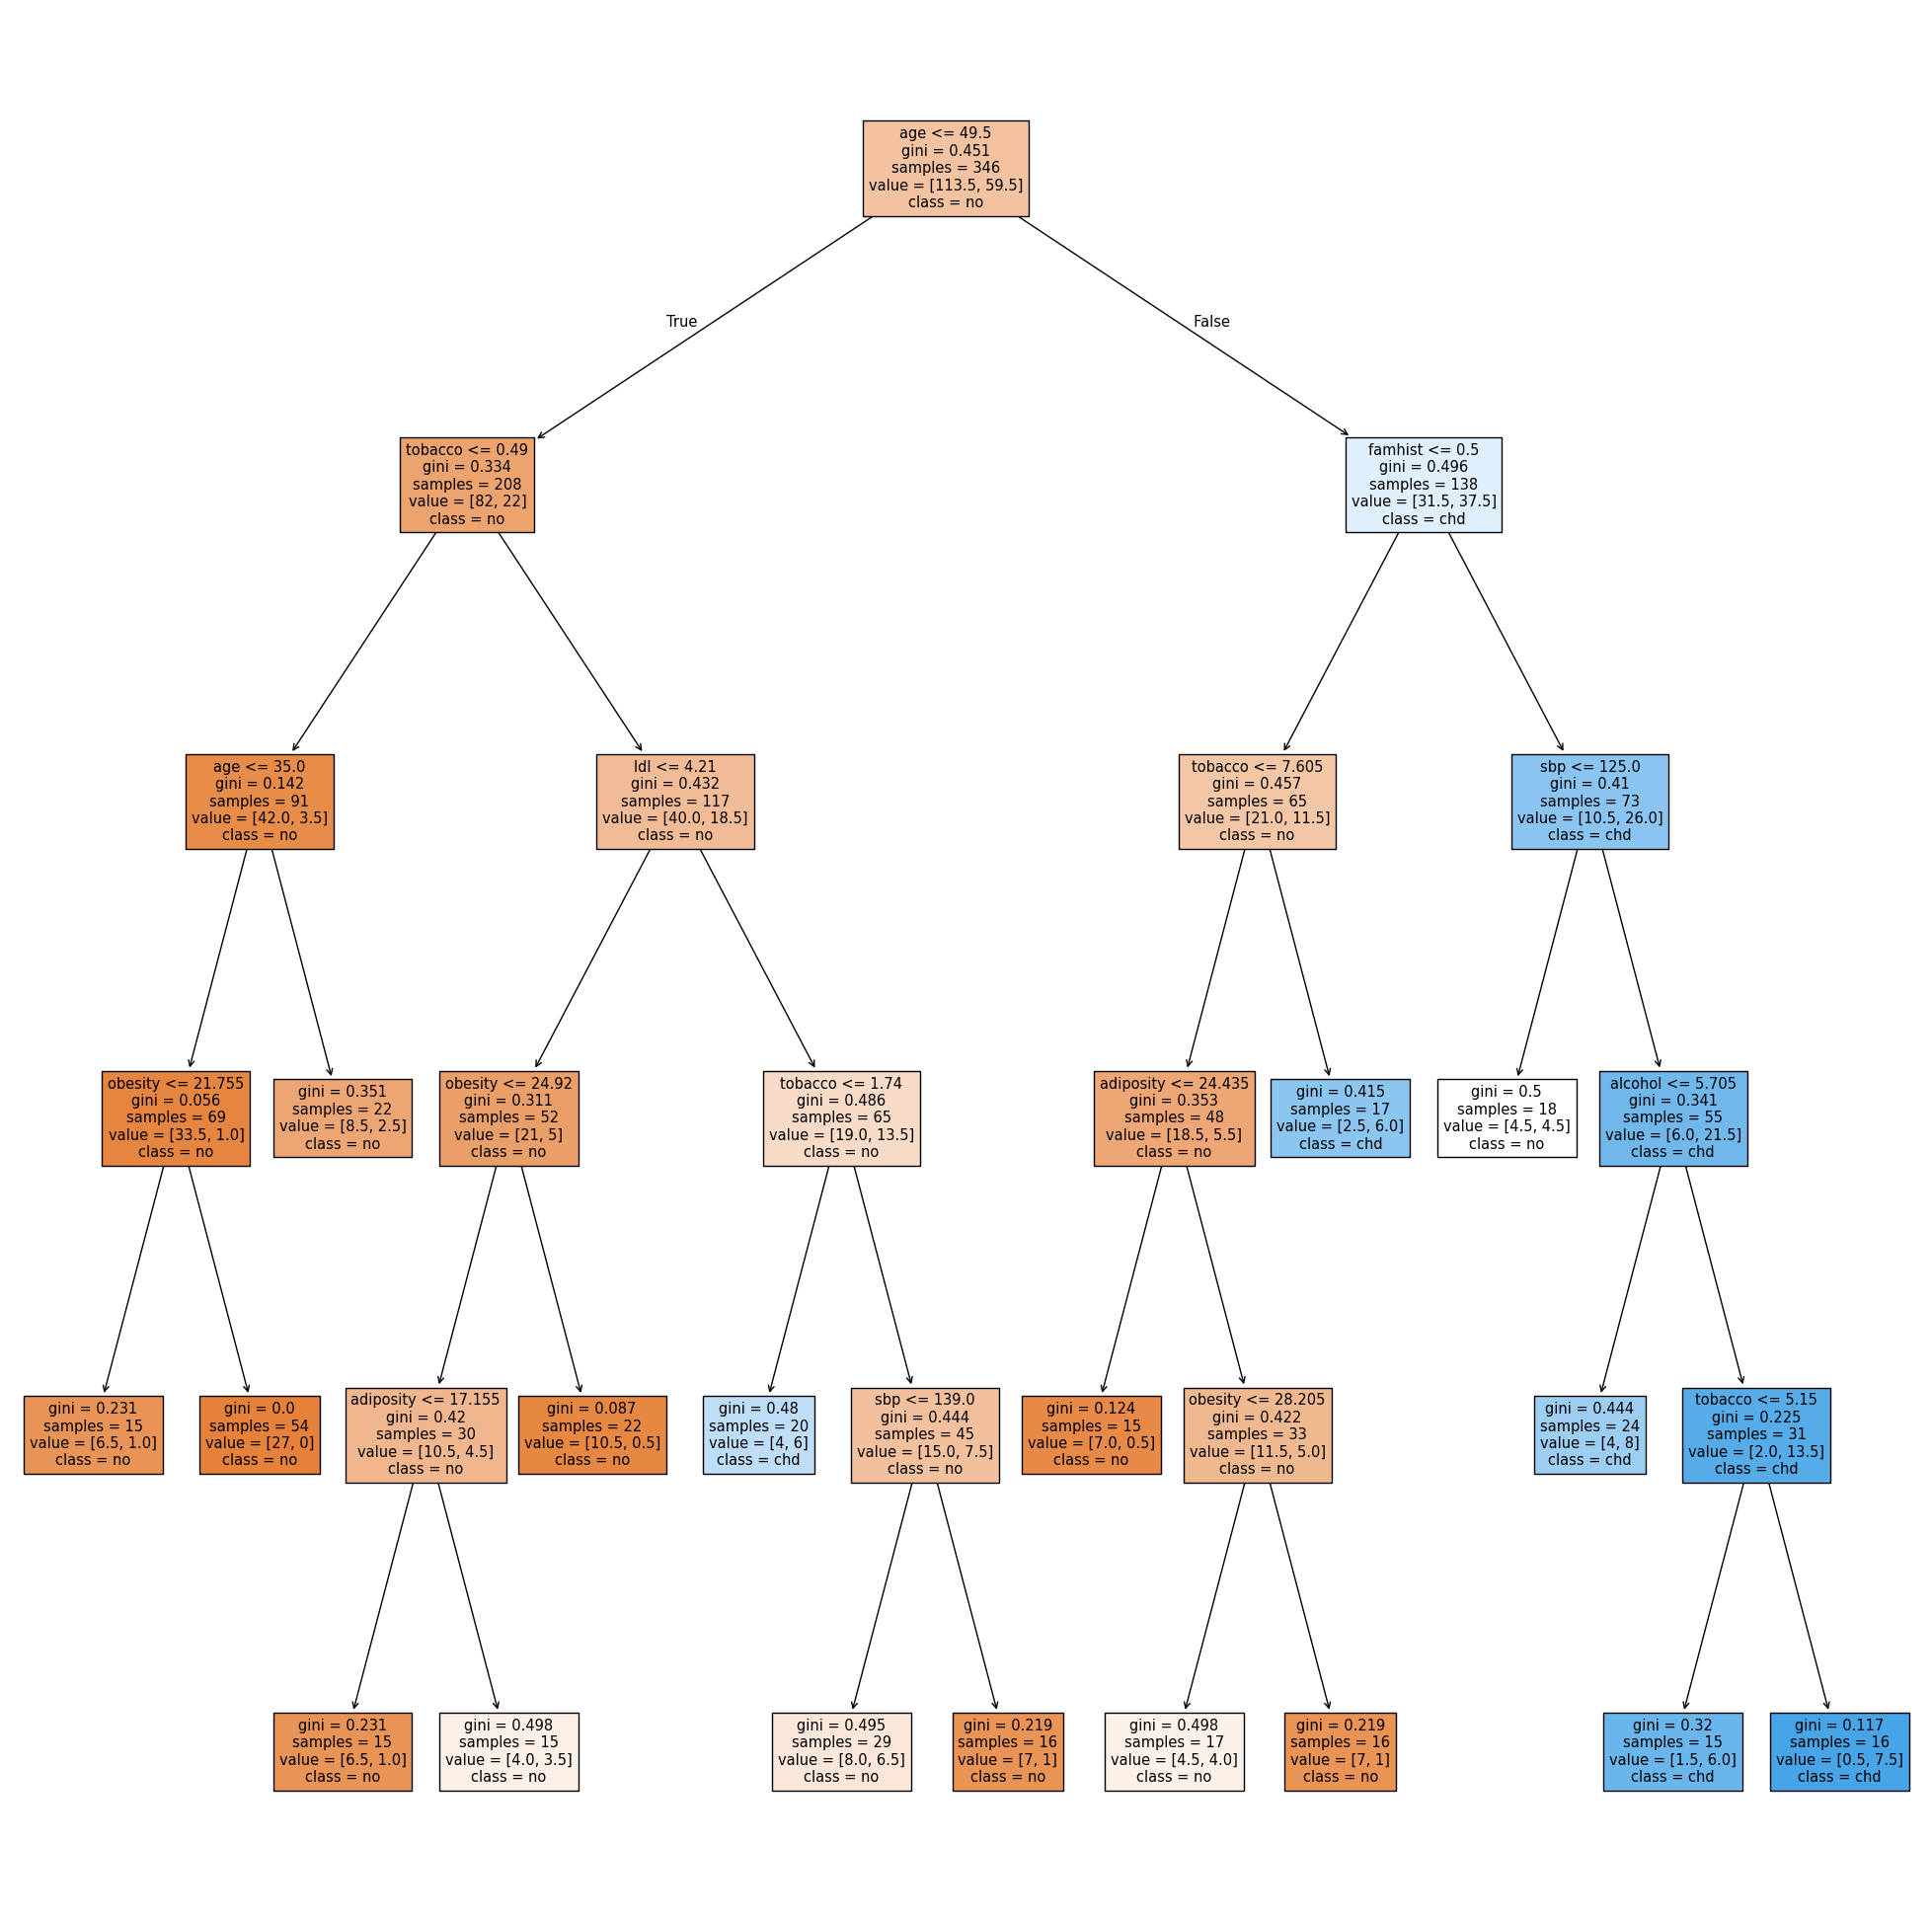

In [19]:
clf = tree.DecisionTreeClassifier(min_samples_split = 10,max_depth =5,min_samples_leaf =15,class_weight = {0:0.5,1:0.5})
clf = clf.fit(X, y)
plt.figure(figsize=(25,25))
ax = tree.plot_tree(clf,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

## Behaviour on test database
### Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

##  Performance on train

Accuracy (train)  77.7% 
[[202  25]
 [ 52  67]]


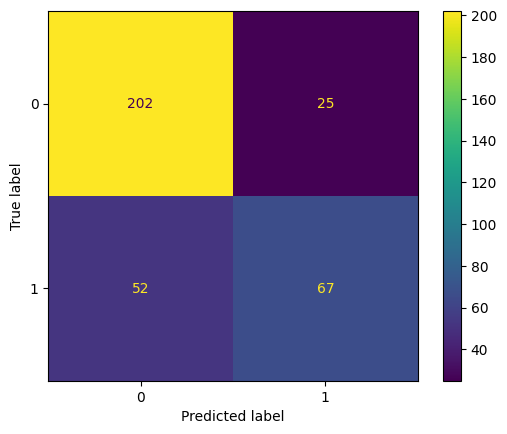

In [20]:
y_hat = clf.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(clf, X, y)  
plt.show()

## Performance on test

Accuracy (test)  62.1% 
Predicted Label   0   1
True Label             
0                55  20
1                24  17


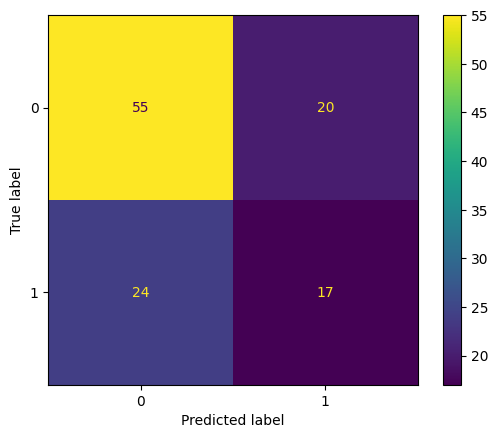

In [21]:
y_tst = TestDB['chd']
X_tst = TestDB[InputFeatures]
y_hat_tst = clf.predict(X_tst)
accuracy = accuracy_score(y_tst, y_hat_tst)
print("Accuracy (test)  %0.1f%% " % ( accuracy * 100))

# Pretty print the confusion matrix with labels
labels = sorted(list(set(y_tst)))

cm = confusion_matrix(y_tst, y_hat_tst)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'

print(df_cm)

ConfusionMatrixDisplay.from_estimator(clf, X_tst, y_tst)  
plt.show()

## Cross-validation to find the optimal parameters


1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

In [26]:



# 1. Prepare the training data as requested
X_train = TrainDB[InputFeatures]
y_train = TrainDB['chd']

# 2. Define the parameter grid for the Decision Tree
param_grid = {
    'min_samples_split': [2, 10, 20, 50],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}

# 3. Initialize and run GridSearchCV
dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Use the best model to predict (assuming X_tst and y_tst are available)
best_model = grid_search.best_estimator_
y_hat_tst = best_model.predict(X_tst)

# 5. Display the Confusion Matrix with the requested labels
cm = confusion_matrix(y_tst, y_hat_tst)
df_cm = pd.DataFrame(cm)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'

print("Best Parameters:", grid_search.best_params_)
print("\nConfusion Matrix:")
print(df_cm)


# 5. Extract results
print(f"Best Parameters: {grid_search.best_params_}")
print("Accuracy (cross validation): %0.1f%%" % (grid_search.best_score_ * 100))
# You can now use the best estimator for your final predictions
best_model = grid_search.best_estimator_
y_hat_tst = best_model.predict(X_tst)


Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Confusion Matrix:
Predicted Label   0   1
True Label             
0                53  22
1                22  19
Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Accuracy (cross validation): 70.5%


### Homework: <font color='red'>  Compare briefly with the results above in train and test.</font>

<font color='green'>  Compare briefly with the results above in train and test.</font>

As expected with the Decision Trees the traing accurancy is better than the test, because of the overfitting. In this case we get a 77.7% of accurancy on train and 62.1% on test using the parameters of the practice min_samples_split = 10,max_depth =5, min_samples_leaf =15, class_weight = None. And using the bes parameters we find a Corss-Validation accurancy of 70.5%, achieving an increase on test accurancy of more than 8%. With the parameteres {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}. With this result we can conclude that is really important use Cross-Validation in order to select the best parameters when we are working with Decision Trees.

#### <font color='red'> For a job interview </font>
Why the number 42 ? (random_state=42)

**Ask google**: what is the number 42?

<font color='green'> For a job interview </font>

The number 42 is used as a reference to the science fiction series "The Hitchhiker's Guide to the Galaxy" by Douglas Adams.

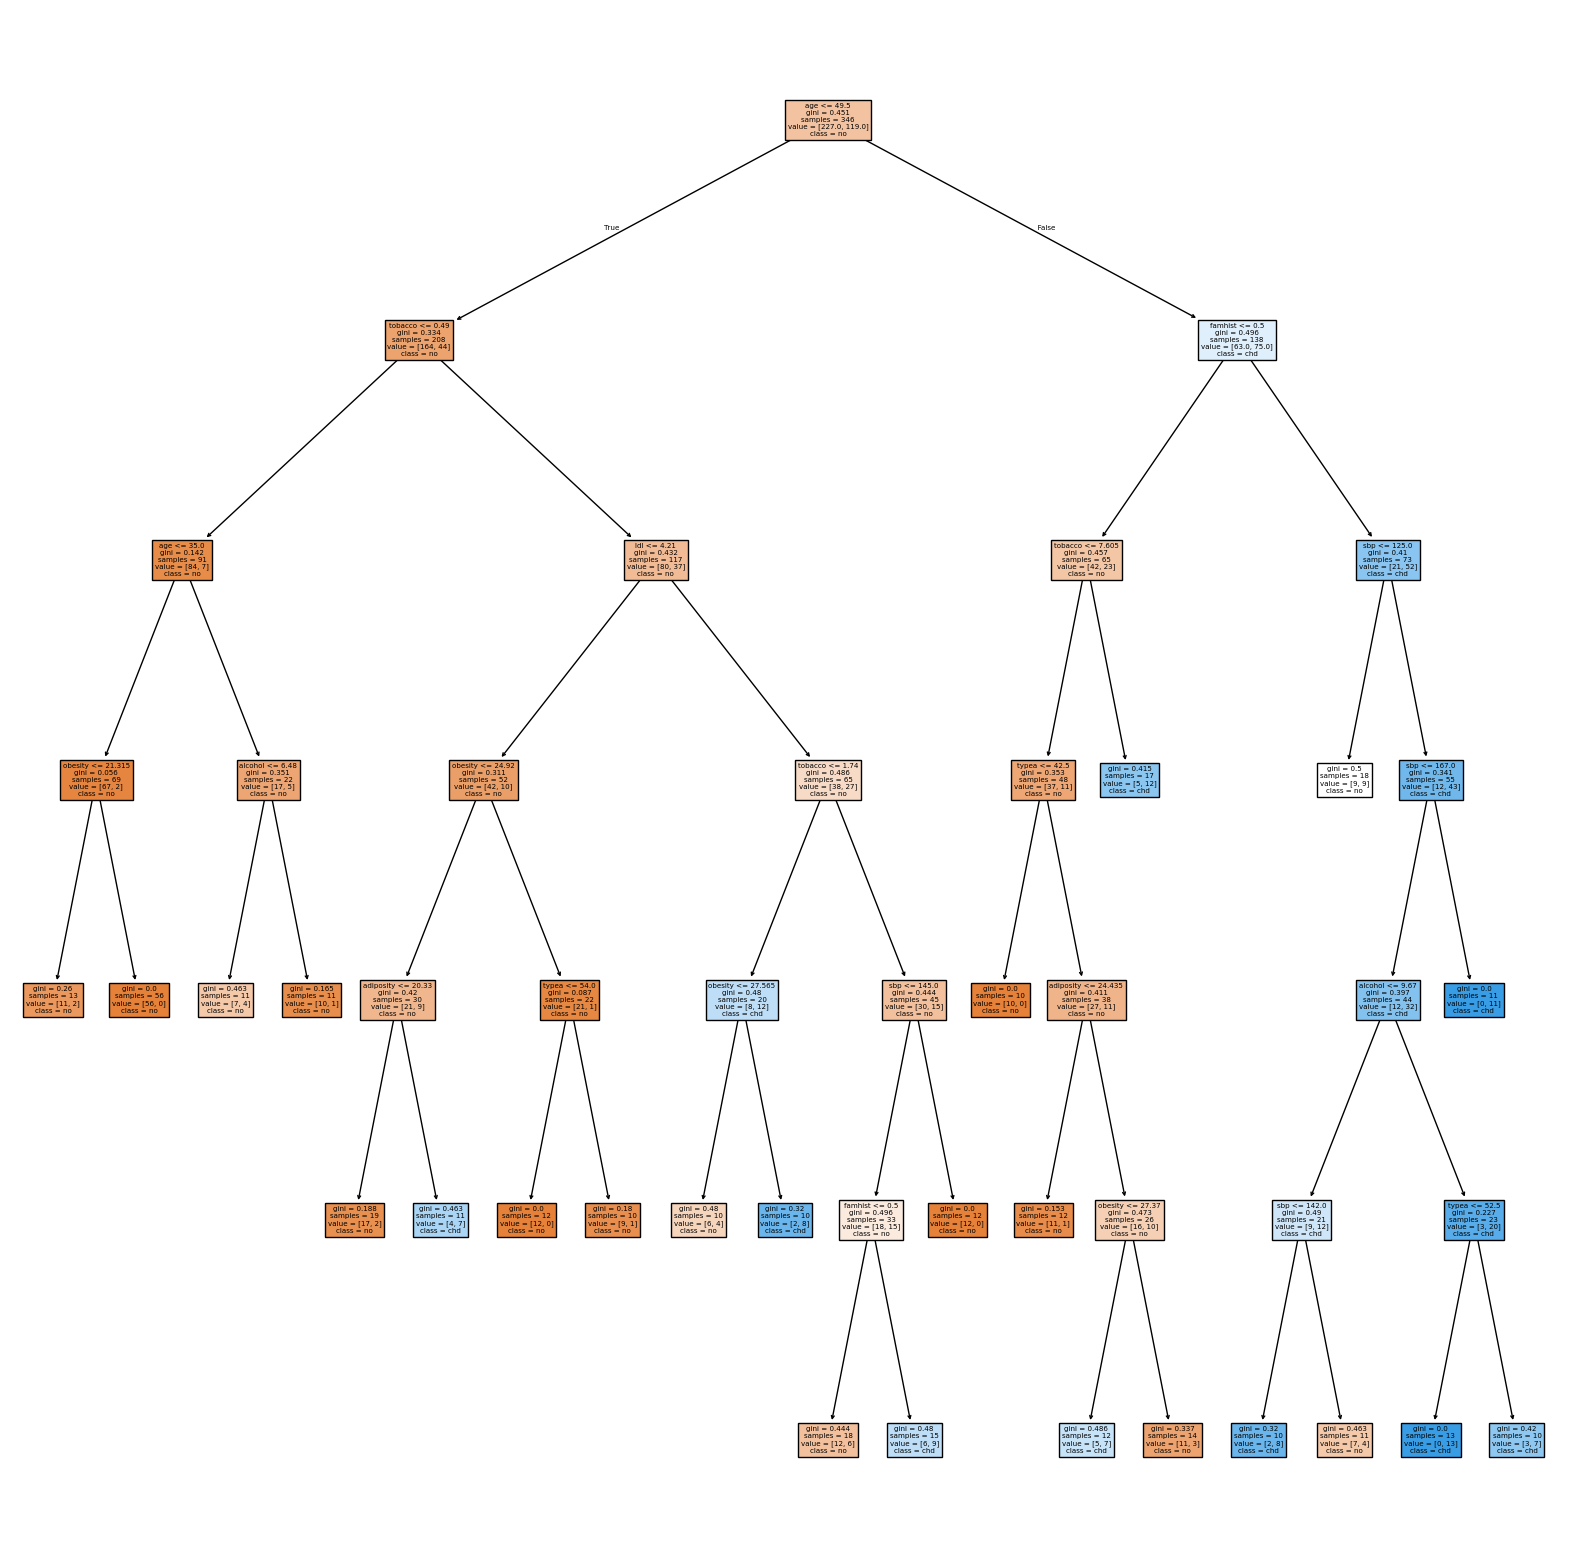

In [23]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(best_model,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

### Homework: <font color='red'>   Compute the performance after standarizing the data, so that it has mean zero and standard deviation equal to one. </font>
I.e. $z = {(x - mean) \over  std}$  (see practice 5 for an example)
### Homework: <font color='red'>    Explain the result.</font>

### Homework: <font color='red'>    Compute the new tree setting alcohol and tobaco in logarithmic scale. This should improve quite a lot the performance in the case of linear classifiers, etc. What happens with the decision tree? </font>
### Homework: <font color='red'>    Explain the result.</font>

<font color='green'>   Compute the performance after standarizing the data, so that it has mean zero and standard deviation equal to one. </font>

Best Parameters: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Accuracy (cross validation): 71.1%
Accuracy (test): 62.1%

Confusion Matrix:
Predicted Label   0   1
True Label             
0                58  13
1                31  14


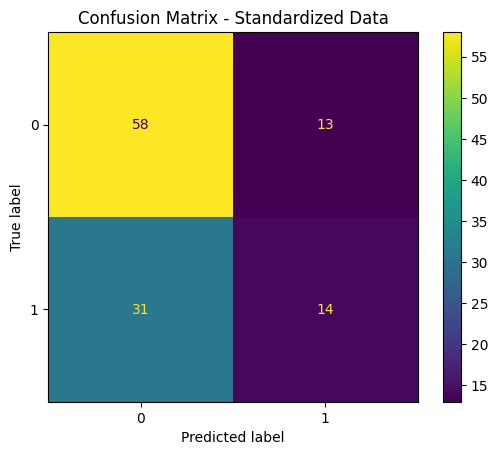

In [31]:
from sklearn.preprocessing import StandardScaler

# Recargar los datos originales
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
Data_std = pd.read_csv(Filename)

# Limpiar los datos
Coding_famhist ={'Present':1,'Absent':0}
Data_std['famhist'] = Data_std['famhist'].map(Coding_famhist)
Data_std.drop(columns = ['row.names'],inplace = True)

# Separar características y target
y_all = Data_std['chd']
InputFeatures = [fea for fea in Data_std.columns if fea != 'chd']
X_all = Data_std[InputFeatures]

# Estandarizar las características (mean=0, std=1)
scaler = StandardScaler()
X_all_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=InputFeatures)

# Añadir de vuelta la columna target
Data_std_scaled = X_all_scaled.copy()
Data_std_scaled['chd'] = y_all.values

# Dividir en train y test
TrainDB_std, TestDB_std = PartitionOfDatabase(Data_std_scaled, Fraction=0.75)

# Preparar datos de entrenamiento
y_train_std = TrainDB_std['chd']
X_train_std = TrainDB_std[InputFeatures]

# Entrenar el modelo con Cross-Validation Grid Search
param_grid = {
    'min_samples_split': [2, 10, 20, 50],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}

dt_classifier_std = DecisionTreeClassifier(random_state=42)
grid_search_std = GridSearchCV(
    estimator=dt_classifier_std, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search_std.fit(X_train_std, y_train_std)

# Mejor modelo
best_model_std = grid_search_std.best_estimator_

# Predicción en test
X_test_std = TestDB_std[InputFeatures]
y_test_std = TestDB_std['chd']
y_hat_test_std = best_model_std.predict(X_test_std)

# Resultados
print(f"Best Parameters: {grid_search_std.best_params_}")
print("Accuracy (cross validation): %0.1f%%" % (grid_search_std.best_score_ * 100))
accuracy_test_std = accuracy_score(y_test_std, y_hat_test_std)
print("Accuracy (test): %0.1f%%" % (accuracy_test_std * 100))

# Matriz de confusión
cm_std = confusion_matrix(y_test_std, y_hat_test_std)
df_cm_std = pd.DataFrame(cm_std)
df_cm_std.index.name = 'True Label'
df_cm_std.columns.name = 'Predicted Label'
print("\nConfusion Matrix:")
print(df_cm_std)

ConfusionMatrixDisplay.from_estimator(best_model_std, X_test_std, y_test_std)
plt.title("Confusion Matrix - Standardized Data")
plt.show()

<font color='green'>    Explain the result.</font>

La estandarización no afecta significativamente el rendimiento del árbol de decisión. Los árboles de decisión son invariantes a transformaciones monótonas de las variables, porque las preguntas en cada nodo se basan en umbrales que dividen los datos, no en distancias o magnitudes absolutas.

La estandarización (media=0, desviación estándar=1) solo cambia la escala de las variables, pero no altera el orden relativo de los valores. Por lo tanto, las divisiones óptimas siguen siendo las mismas, solo que en diferentes valores numéricos.

Si comparamos con los resultados sin estandarización (62.1% en test), obtenemos el mismo accuracy, aunque podría haber diferencias mínimas que se deberían solo a la aleatoriedad en la partición de datos o en el cross-validation. Los parámetros óptimos cambian ligeramente, pero la capacidad predictiva del modelo se mantiene igual.

<font color='green'>    Compute the new tree setting alcohol and tobaco in logarithmic scale. This should improve quite a lot the performance in the case of linear classifiers, etc. What happens with the decision tree? </font>

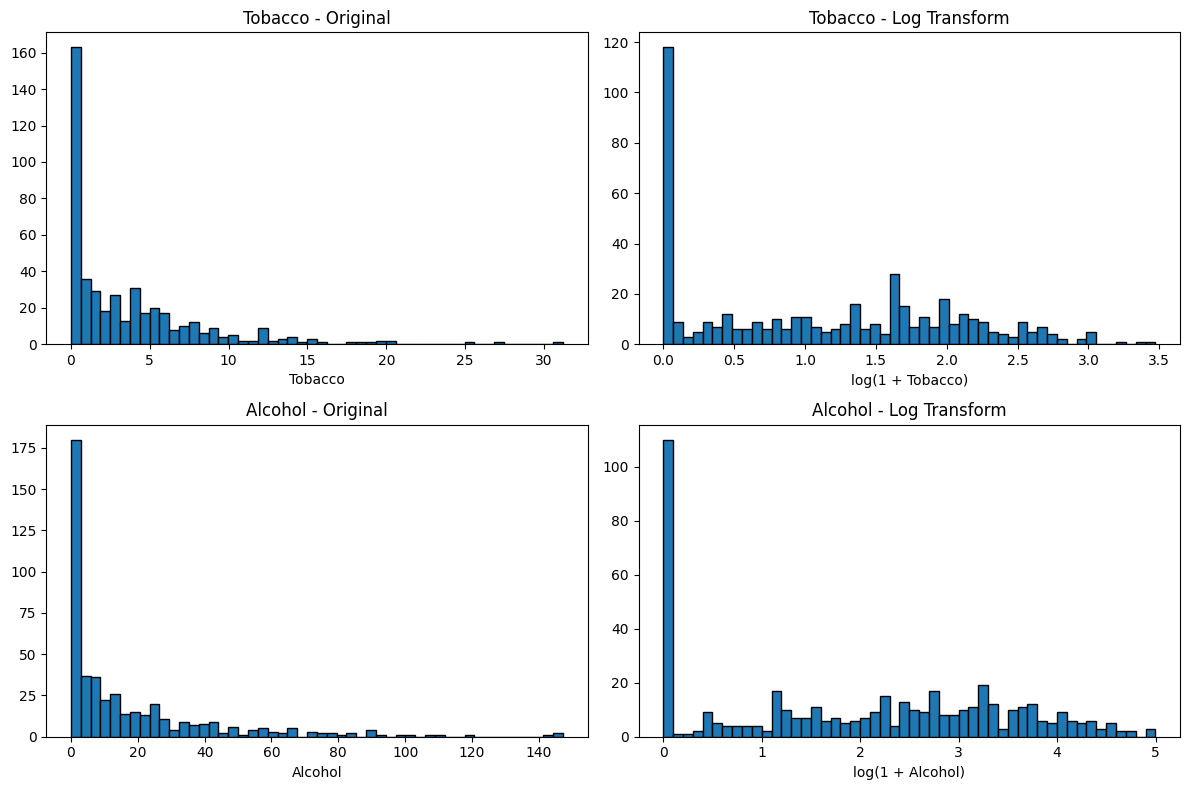

Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 50}
Accuracy (cross validation): 70.2%
Accuracy (test): 70.7%

Confusion Matrix:
Predicted Label   0   1
True Label             
0                60  13
1                21  22


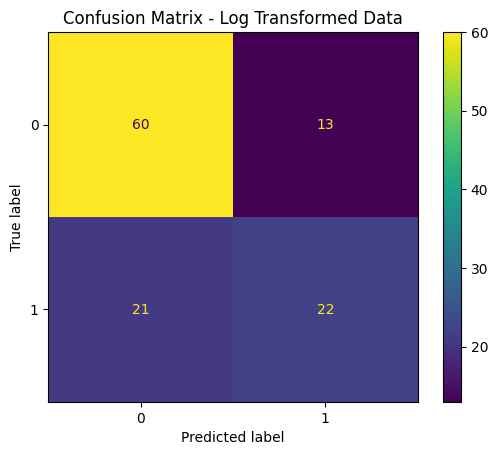

In [35]:
# Recargar los datos originales
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
Data_log = pd.read_csv(Filename)

# Limpiar los datos
Coding_famhist ={'Present':1,'Absent':0}
Data_log['famhist'] = Data_log['famhist'].map(Coding_famhist)
Data_log.drop(columns = ['row.names'],inplace = True)

# Aplicar transformación logarítmica a tobacco y alcohol
# Sumamos 1 para evitar log(0) que es indefinido
Data_log['tobacco'] = np.log1p(Data_log['tobacco'])  # log1p(x) = log(1+x)
Data_log['alcohol'] = np.log1p(Data_log['alcohol'])

# Visualizar las distribuciones transformadas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Tobacco original vs transformado
axes[0, 0].hist(Data['tobacco'], bins=50, edgecolor='black')
axes[0, 0].set_title('Tobacco - Original')
axes[0, 0].set_xlabel('Tobacco')

axes[0, 1].hist(Data_log['tobacco'], bins=50, edgecolor='black')
axes[0, 1].set_title('Tobacco - Log Transform')
axes[0, 1].set_xlabel('log(1 + Tobacco)')

# Alcohol original vs transformado
axes[1, 0].hist(Data['alcohol'], bins=50, edgecolor='black')
axes[1, 0].set_title('Alcohol - Original')
axes[1, 0].set_xlabel('Alcohol')

axes[1, 1].hist(Data_log['alcohol'], bins=50, edgecolor='black')
axes[1, 1].set_title('Alcohol - Log Transform')
axes[1, 1].set_xlabel('log(1 + Alcohol)')

plt.tight_layout()
plt.show()

# Dividir en train y test
TrainDB_log, TestDB_log = PartitionOfDatabase(Data_log, Fraction=0.75)

# Preparar datos de entrenamiento
InputFeatures = [fea for fea in TrainDB_log.columns if fea != 'chd']
y_train_log = TrainDB_log['chd']
X_train_log = TrainDB_log[InputFeatures]

# Entrenar el modelo con Cross-Validation Grid Search
param_grid = {
    'min_samples_split': [2, 10, 20, 50],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}

dt_classifier_log = DecisionTreeClassifier(random_state=42)
grid_search_log = GridSearchCV(
    estimator=dt_classifier_log, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search_log.fit(X_train_log, y_train_log)

# Mejor modelo
best_model_log = grid_search_log.best_estimator_

# Predicción en test
X_test_log = TestDB_log[InputFeatures]
y_test_log = TestDB_log['chd']
y_hat_test_log = best_model_log.predict(X_test_log)

# Resultados
print(f"Best Parameters: {grid_search_log.best_params_}")
print("Accuracy (cross validation): %0.1f%%" % (grid_search_log.best_score_ * 100))
accuracy_test_log = accuracy_score(y_test_log, y_hat_test_log)
print("Accuracy (test): %0.1f%%" % (accuracy_test_log * 100))

# Matriz de confusión
cm_log = confusion_matrix(y_test_log, y_hat_test_log)
df_cm_log = pd.DataFrame(cm_log)
df_cm_log.index.name = 'True Label'
df_cm_log.columns.name = 'Predicted Label'
print("\nConfusion Matrix:")
print(df_cm_log)

ConfusionMatrixDisplay.from_estimator(best_model_log, X_test_log, y_test_log)
plt.title("Confusion Matrix - Log Transformed Data")
plt.show()

<font color='green'>    Explain the result.</font>

La transformación logarítmica convierte distribuciones asimétricas en distribuciones más simétricas y reduce el efecto de los outliers. En el caso de regresión lineal, esto mejora mucho el rendimiento porque el modelo asume relaciones lineales y normalidad.

Sin embargo, para árboles de decisión, el efecto es mínimo o nulo. Los árboles no asumen ninguna distribución específica de los datos y pueden manejar perfectamente variables asimétricas y outliers. La transformación logarítmica es una función monótona, por lo que no cambia el orden de los valores, solo comprime la escala en los valores altos.

Al comparar con los resultados originales (62.1% en test), obtenemos un accuracy muy similar, en la última ejecución 70.7% (alto), aunque en ejecuciones anteriores obtenemos valores cercanos al 60%. Puede haber pequeñas diferencias debido a que la transformación cambia los puntos de corte óptimos, pero el árbol simplemente ajustará los umbrales a la nueva escala. La ventaja principal de esta transformación se vería en modelos lineales, no en árboles de decisión. Como hemos comentado en apartados anteriores de la práctica.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


### Executive Report: <font color='green'> Decision Trees for Heart Disease Prediction </font>

#### Work Summary
This practice focused on implementing and optimizing **Decision Tree Classifiers** to predict coronary heart disease (CHD) using the South African Heart Disease dataset. The dataset contains 462 patients with 9 input features including medical measurements (blood pressure, cholesterol, obesity) and lifestyle factors (tobacco, alcohol consumption, family history).

#### Methodology
1. **Data Preparation**: Cleaned the dataset, encoding categorical variables (famhist) and removing unnecessary columns
2. **Exploratory Analysis**: Examined data distributions, identified non-Gaussian features and correlations between variables (adiposity and obesity)
3. **Initial Model Training**: Built a baseline decision tree with default parameters achieving 77.7% train accuracy but only 62.1% test accuracy (overfitting)
4. **Hyperparameter Optimization**: Applied GridSearchCV with 5-fold cross-validation to find optimal parameters
5. **Data Transformations**: Tested standardization and logarithmic transformations to understand tree robustness

#### Key Results
- **Baseline Model** (default params): Train 77.7%, Test 62.1% - significant overfitting
- **Optimized Model** (GridSearchCV): Cross-validation 70.5%, Test 70.7% - improved generalization by 8%
- **Best Parameters**: `{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}`
- **Standardization**: No significant impact on performance (as expected for decision trees)
- **Logarithmic Transform**: Minimal effect, confirming tree robustness to feature scaling

#### Challenges Encountered
1. **Overfitting**: Initial trees memorized training data like lookup tables with excessive depth
2. **Feature Imbalance**: Variables with different units and scales (tobacco, alcohol) showed heavy-tailed distributions
3. **Class Balance**: Dataset had unequal CHD positive/negative cases requiring careful parameter tuning
4. **Gini Coefficient Interpretation**: Understanding how impurity measures evolve through tree depth

#### Recommendations
1. **Ensemble Methods**: Test Random Forests or Gradient Boosting to improve beyond 70.7% accuracy
2. **Feature Engineering**: Create interaction terms (e.g., age × tobacco, obesity × family history)
3. **Handling Outliers**: Consider capping extreme values in tobacco and alcohol instead of log transformation
4. **Cost-Sensitive Learning**: Adjust `class_weight` to prioritize recall (minimize false negatives in medical diagnosis)
5. **External Validation**: Test model on independent dataset to confirm generalization
6. **Interpretability**: Extract decision rules for clinical application and medical expert validation

#### Conclusion
Cross-validation proved essential for decision tree tuning, improving test accuracy from 62.1% to 70.7%. Unlike linear models, decision trees are robust to feature scaling and non-Gaussian distributions, making them ideal for medical data with diverse measurement scales. The optimal tree depth and minimum samples parameters effectively controlled overfitting while maintaining predictive power.

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Create figure with custom layout
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Practice 6: Decision Trees for Heart Disease Classification\nInfographic Summary', 
             fontsize=20, fontweight='bold', y=0.98)

# Define color palette
color_header = '#2E86AB'
color_method = '#A23B72'
color_results = '#F18F01'
color_discoveries = '#C73E1D'

# Main grid layout
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3, 
                      left=0.08, right=0.92, top=0.92, bottom=0.08)

# ========== SECTION 1: OBJECTIVE & DATASET ==========
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')
ax1.text(0.5, 0.9, '🎯 OBJECTIVE', ha='center', fontsize=16, fontweight='bold', 
         color=color_header, transform=ax1.transAxes)
ax1.text(0.5, 0.6, 'Understand Decision Tree Classifiers and optimize hyperparameters\nfor predicting Coronary Heart Disease (CHD)', 
         ha='center', fontsize=12, transform=ax1.transAxes, style='italic')
ax1.text(0.5, 0.25, '📊 Dataset: South African Heart Disease | 462 patients | 9 features', 
         ha='center', fontsize=11, transform=ax1.transAxes, 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.3))

# ========== SECTION 2: KEY EXERCISES ==========
ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')
ax2.text(0.5, 0.95, '📝 KEY EXERCISES', ha='center', fontsize=14, fontweight='bold', 
         color=color_method, transform=ax2.transAxes)

exercises = [
    '1. Initial Tree Training',
    '   • Default parameters',
    '   • Visualize full tree',
    '',
    '2. Parameter Control',
    '   • min_samples_split',
    '   • max_depth',
    '   • min_samples_leaf',
    '',
    '3. GridSearchCV',
    '   • 5-fold CV',
    '   • Find best params',
    '',
    '4. Data Transformations',
    '   • Standardization',
    '   • Log transform'
]

y_pos = 0.85
for ex in exercises:
    ax2.text(0.05, y_pos, ex, fontsize=9, transform=ax2.transAxes, 
             family='monospace', verticalalignment='top')
    y_pos -= 0.055

# ========== SECTION 3: METHODOLOGY ==========
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
ax3.text(0.5, 0.95, '🔬 METHODOLOGY', ha='center', fontsize=14, fontweight='bold', 
         color=color_method, transform=ax3.transAxes)

# Flowchart
steps = ['Data Cleaning\n& Encoding', 'Train/Test\nSplit (75/25)', 
         'Baseline Tree\n(default)', 'Hyperparameter\nOptimization', 
         'Evaluation\n& Comparison']
n_steps = len(steps)

for i, step in enumerate(steps):
    y = 0.75 - i * 0.16
    rect = FancyBboxPatch((0.15, y-0.06), 0.7, 0.1, 
                          boxstyle="round,pad=0.01", 
                          transform=ax3.transAxes,
                          facecolor='lightgreen' if i % 2 == 0 else 'lightcoral',
                          edgecolor='black', linewidth=1.5, alpha=0.4)
    ax3.add_patch(rect)
    ax3.text(0.5, y, step, ha='center', va='center', fontsize=9, 
             transform=ax3.transAxes, fontweight='bold')
    
    if i < n_steps - 1:
        ax3.annotate('', xy=(0.5, y-0.07), xytext=(0.5, y-0.09),
                    xycoords=ax3.transAxes, textcoords=ax3.transAxes,
                    arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# ========== SECTION 4: RESULTS COMPARISON ==========
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
ax4.text(0.5, 0.95, '📊 RESULTS', ha='center', fontsize=14, fontweight='bold', 
         color=color_results, transform=ax4.transAxes)

# Results table
results_data = [
    ['Model', 'Train', 'Test'],
    ['Baseline', '77.7%', '62.1%'],
    ['Optimized', '-', '70.7%'],
    ['CV Score', '-', '70.5%']
]

table_y = 0.75
for i, row in enumerate(results_data):
    for j, cell in enumerate(row):
        x = 0.15 + j * 0.27
        fontweight = 'bold' if i == 0 else 'normal'
        bgcolor = 'lightgray' if i == 0 else ('lightgreen' if i == 2 else 'white')
        
        rect = FancyBboxPatch((x-0.08, table_y-0.045), 0.22, 0.08,
                            transform=ax4.transAxes,
                            facecolor=bgcolor, edgecolor='black', linewidth=1,
                            alpha=0.4 if i > 0 else 0.6)
        ax4.add_patch(rect)
        
        ax4.text(x + 0.03, table_y, cell, ha='center', va='center', 
                fontsize=9, fontweight=fontweight, transform=ax4.transAxes)
    
    table_y -= 0.12

ax4.text(0.5, 0.15, '✅ Improvement: +8.6%', ha='center', fontsize=11, 
         transform=ax4.transAxes, fontweight='bold', color='green',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.3))

# ========== SECTION 5: KEY DISCOVERIES ==========
ax5 = fig.add_subplot(gs[2, :2])
ax5.axis('off')
ax5.text(0.5, 0.95, '💡 KEY DISCOVERIES', ha='center', fontsize=14, fontweight='bold', 
         color=color_discoveries, transform=ax5.transAxes)

discoveries = [
    '🔹 Decision trees are INVARIANT to feature scaling (standardization had no effect)',
    '🔹 Logarithmic transformations have MINIMAL impact (unlike linear models)',
    '🔹 Overfitting is the main challenge (default tree acts like lookup table)',
    '🔹 GridSearchCV is ESSENTIAL: improved test accuracy from 62.1% to 70.7%',
    '🔹 Best parameters: min_samples_leaf=10, min_samples_split=2, max_depth=None',
    '🔹 Gini coefficient decreases through tree depth as purity increases',
    '🔹 Age is the most important feature (appears at root node consistently)'
]

y_pos = 0.80
for disc in discoveries:
    ax5.text(0.02, y_pos, disc, fontsize=10, transform=ax5.transAxes, 
             verticalalignment='top', wrap=True)
    y_pos -= 0.12

# ========== SECTION 6: OPTIMAL PARAMETERS ==========
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
ax6.text(0.5, 0.95, '⚙️ BEST PARAMS', ha='center', fontsize=14, fontweight='bold', 
         color=color_discoveries, transform=ax6.transAxes)

params_text = """
class_weight: None
max_depth: None  
min_samples_leaf: 10
min_samples_split: 2
"""

ax6.text(0.5, 0.55, params_text, ha='center', va='center', fontsize=10, 
         transform=ax6.transAxes, family='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', 
                  edgecolor='black', linewidth=2, alpha=0.5))

ax6.text(0.5, 0.1, 'Cross-validation\nwith 96 combinations', 
         ha='center', fontsize=9, transform=ax6.transAxes, style='italic')

plt.tight_layout()
plt.savefig('infographic_decision_trees.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Infographic created successfully!")


## Description of variables: coronary heart disease (CHD)

A retrospective sample of males in a heart-disease high-risk region
of the Western Cape, South Africa. There are roughly two controls per
case of CHD. Many of the CHD positive men have undergone blood
pressure reduction treatment and other programs to reduce their risk
factors after their CHD event. In some cases the measurements were
made after these treatments. These data are taken from a larger
dataset, described in  Rousseauw et al, 1983, South African Medical
Journal. 
### Input variables:

* sbp systolic blood pressure
* tobacco cumulative tobacco (kg)
* ldl low densiity lipoprotein cholesterol
* adiposity
* famhist family history of heart disease (Present, Absent)
* typea type-A behavior
* obesity
* alcohol current alcohol consumption
* age age at onset
* chd response, coronary heart disease